<a href="https://colab.research.google.com/github/Allan-Robert/Aulas_Python_20252/blob/main/meteorologicos_aracaju.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
meteo=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/meteo2020aju.xlsx")
meteo.head(1)
meteo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   data                 8784 non-null   datetime64[ns]
 1   hora                 8784 non-null   int64         
 2   pressão              8784 non-null   float64       
 3   temperatura_ar       8784 non-null   float64       
 4   temperatura_máxima   8784 non-null   float64       
 5   temperatura_mínima   8784 non-null   float64       
 6   umidade_relativa_ar  8784 non-null   int64         
 7   dir_vento_angulo     8784 non-null   int64         
 8   vento_rajada_ms      8784 non-null   float64       
 9   vel_vento_ms         8784 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(3)
memory usage: 686.4 KB


In [ ]:
meteo[['temperatura_máxima','temperatura_mínima']].describe()

,temperatura_máxima,temperatura_mínima
count,8784.000000,8784.000000
mean,27.367099,26.324419
std,2.403152,2.153276
min,19.800000,19.500000
25%,25.600000,24.800000
50%,27.100000,26.300000
75%,29.100000,27.800000
max,35.200000,32.100000


In [ ]:
meteo.iloc[:,[8,9]].describe()

,vento_rajada_ms,vel_vento_ms
count,8784.000000,8784.000000
mean,5.934392,2.436134
std,2.070401,1.312400
min,1.100000,0.200000
25%,4.400000,1.300000
50%,6.000000,2.200000
75%,7.400000,3.400000
max,14.000000,7.000000


Text(0, 0.5, 'Velocidade em m/s')

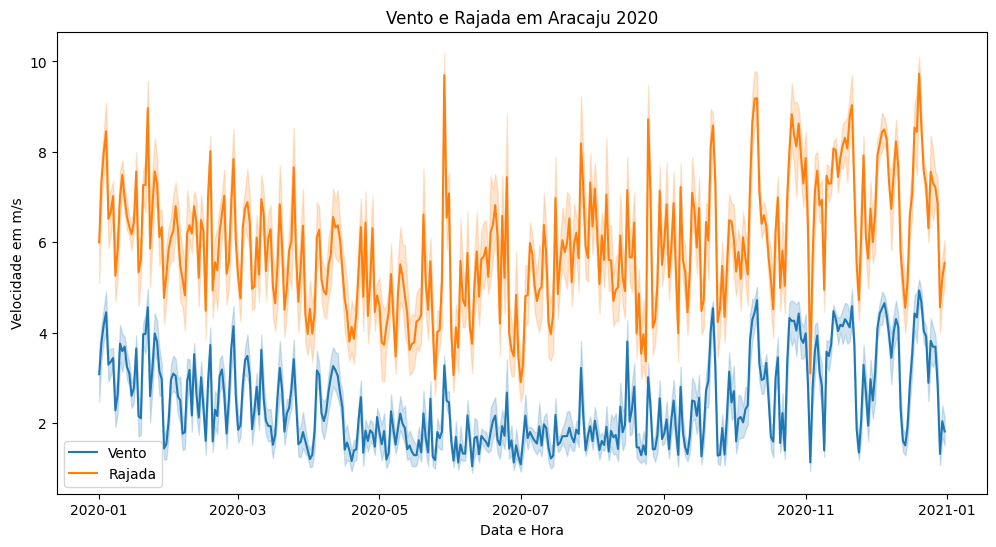

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=meteo,x='data',y='vel_vento_ms',label='Vento')
sns.lineplot(data=meteo,x='data',y='vento_rajada_ms',label='Rajada')
plt.legend()
plt.title("Vento e Rajada em Aracaju 2020")
plt.xlabel('Data')
plt.ylabel("Velocidade em m/s")

Crie uma nova variável chamada Turno com as seguintes respostas:
* Matutino 6:00 às 11:59 --- Vespertino 12:00 às 18:59,
* Noturno 19:00 às 23:59 --- Madrugada 00:00 às 05:59.

In [ ]:
intervalos=[0,6,12,19,24]
nomes=['Madrugada','Matutino','Vespertino','Noturno']
meteo['Turno']=pd.cut(meteo.hora,bins=intervalos,labels=nomes,right=False)
meteo['Turno'].value_counts()

,count
Turno,
Vespertino,2562
Madrugada,2196
Matutino,2196
Noturno,1830


In [ ]:
meteo.groupby('Turno')['vel_vento_ms'].describe()

,count,mean,std,min,25%,50%,75%,max
Turno,,,,,,,,
Madrugada,2196.0,2.273042,1.237339,0.2,1.2,2.0,3.3,5.8
Matutino,2196.0,2.028415,1.092043,0.2,1.1,1.7,2.8,7.0
Vespertino,2562.0,2.936456,1.307718,0.4,1.8,2.8,3.9,6.4
Noturno,1830.0,2.420656,1.423212,0.3,1.2,2.0,3.6,6.7


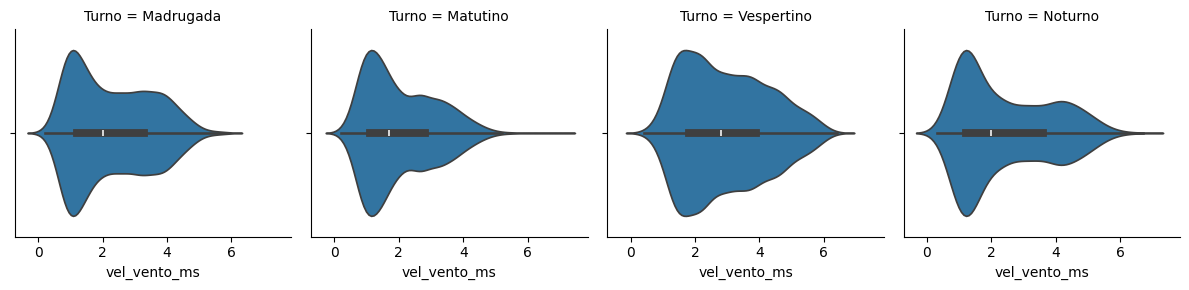

In [ ]:
g=sns.FacetGrid(meteo,col='Turno')
g.map(sns.violinplot,'vel_vento_ms')

##Crie uma nova variável chamada Estação com as seguintes categorias:

* Primavera: 22 de setembro a 20 de dezembro;
* Verão: 21 de dezembro a 19 de março;
* Outono: 20 de março a 20 de junho;
* Inverno: 21 de junho a 21 de setembro.

In [ ]:
def estacao(x):
  if x<= pd.to_datetime('2020-3-19'):
    return 'Verão'
  elif x<= pd.to_datetime('2020-6-20'):
    return 'Outono'
  elif x<= pd.to_datetime('2020-9-21'):
    return 'Inverno'
  elif x<= pd.to_datetime('2020-12-20'):
    return 'Primavera'
  else: return 'Verão'

meteo["Estação"]=meteo['data'].apply(estacao)
meteo.head(1)

,data,hora,pressão,temperatura_ar,temperatura_máxima,temperatura_mínima,umidade_relativa_ar,dir_vento_angulo,vento_rajada_ms,vel_vento_ms,Turno,Estação
0,2020-01-01,0,1012.9,27.2,27.2,26.6,62,53,6.5,3.6,Madrugada,Verão


In [ ]:
meteo.groupby(['Turno','Estação'])['temperatura_ar'].describe()

count       mean       std   min    25%   50%     75%  \
Turno      Estação                                                            
Madrugada  Inverno    558.0  24.053047  1.038115  20.6  23.40  24.3  24.800   
           Outono     558.0  25.922581  1.376186  22.4  25.00  25.9  26.900   
           Primavera  540.0  25.759444  0.719645  22.4  25.40  25.9  26.300   
           Verão      540.0  27.103889  0.857491  24.1  26.60  27.2  27.700   
Matutino   Inverno    558.0  23.745699  1.425521  19.7  22.60  23.8  24.600   
           Outono     558.0  25.330824  1.640472  21.4  24.10  25.2  26.400   
           Primavera  540.0  26.021852  1.467497  22.0  25.20  25.9  26.800   
           Verão      540.0  26.918889  1.378275  23.9  26.00  26.8  27.600   
Vespertino Inverno    651.0  27.366206  1.411446  22.3  26.75  27.7  28.300   
           Outono     651.0  29.029186  2.052100  23.5  27.90  29.4  30.500   
           Primavera  630.0  29.273333  0.968102  23.3  28.80  29.4  29.800   
           Verão      630.0  30.382698  1.252306  25.4  29.60  30.7  31.300   
Noturno    Inverno    465.0  25.165376  1.229480  21.9  24.40  25.1  26.000   
           Outono     465.0  26.980645  1.553934  23.4  25.90  26.9  28.100   
           Primavera  450.0  26.757111  1.052457  23.6  26.20  26.7  27.400   
           Verão      450.0  28.301333  1.121841  25.0  27.50  28.2  28.975   

                       max  
Turno      Estação          
Madrugada  Inverno    26.1  
           Outono     29.1  
           Primavera  27.1  
           Verão      28.8  
Matutino   Inverno    27.4  
           Outono     30.9  
           Primavera  29.9  
           Verão      31.2  
Vespertino Inverno    29.7  
           Outono     33.6  
           Primavera  33.4  
           Verão      33.2  
Noturno    Inverno    28.6  
           Outono     30.9  
           Primavera  30.5  
           Verão      31.6

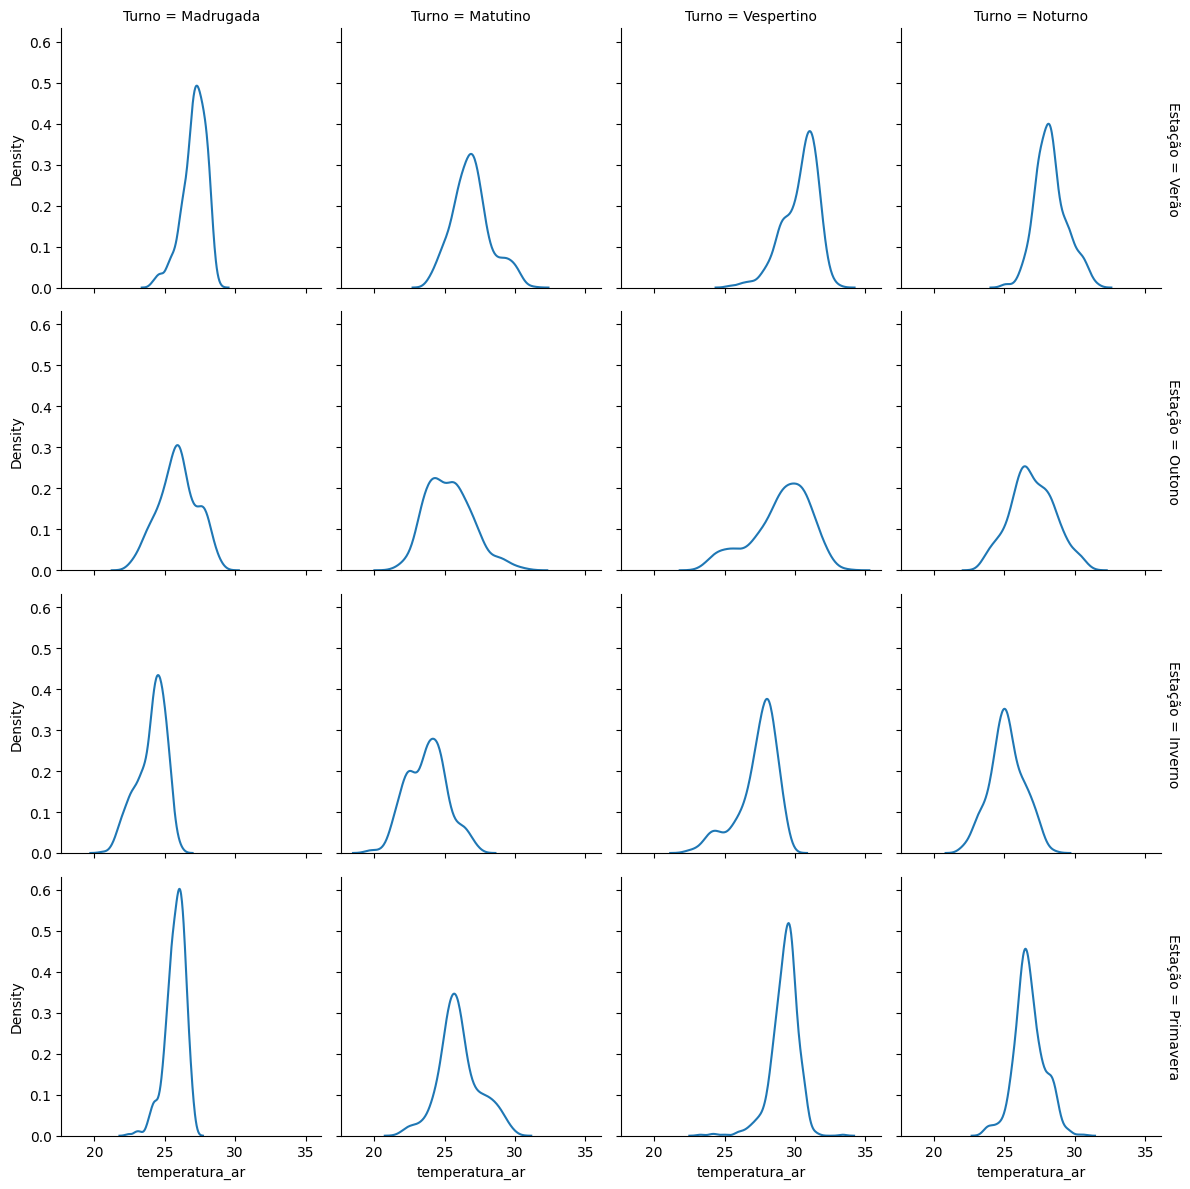

In [ ]:
g=sns.FacetGrid(meteo,col='Turno',row='Estação',margin_titles=True)
g.map(sns.kdeplot,'temperatura_ar')

In [ ]:
meteo['vel_vento_ms'].max()

7.0

In [ ]:
# prompt: https://pt.wikipedia.org/wiki/Escala_de_Beaufort  use a primeira tabela desse site. Quero criar uma coluna com nome Beaufort nos dados de nome meteo. Use a função cut e tome a coluna vel_vento_ms como a velocidade do vento. A designação na tabela do site é a nomeação a ser usada. Crie somente até a linha referente a Brisa moderada
# Defina os limites para a escala de Beaufort (em m/s)
# Use os valores da primeira tabela do link fornecido, convertendo km/h para m/s (dividindo por 3.6)
# Os limites são os valores superiores de cada categoria
limites_beaufort = [0,0.3, 1.5, 3.3, 5.4, 7.9] # Até Brisa moderada

# Defina os rótulos para cada categoria da escala de Beaufort
rotulos_beaufort = ['Calmaria','Aragem', 'Brisa leve', 'Brisa fraca', 'Brisa moderada'] # Até Brisa moderada

# Crie a nova coluna 'Beaufort' usando pd.cut
meteo['Beaufort'] = pd.cut(meteo['vel_vento_ms'],
                            bins=limites_beaufort, # Adiciona 0 como limite inferior e um valor maior que o máximo como limite superior
                            labels=rotulos_beaufort, # Adiciona None para valores fora da faixa de rótulos definidos (acima de brisa moderada)
                            ) # Inclui o limite superior no intervalo



In [ ]:
# tabela cruzada
pd.crosstab(meteo['Estação'],meteo['Beaufort'])

Beaufort,Calmaria,Aragem,Brisa leve,Brisa fraca,Brisa moderada
Estação,,,,,
Inverno,6,1109,882,222,13
Outono,4,1031,1000,192,5
Primavera,4,419,628,1027,82
Verão,3,405,958,762,32
